# Pressure Anomaly Detection using Isolation Forest

## Project Overview

This notebook develops an unsupervised machine learning model to detect abnormal pressure behavior in oil wells using the Volve Production Dataset.

Pressure anomalies often indicate operational issues such as equipment malfunction, tubing blockage, sensor failure, or abnormal reservoir conditions. Detecting these anomalies at an early stage enables timely intervention and helps improve operational reliability.

### Objectives

- Perform pressure-focused exploratory data analysis (EDA)
- Clean and preprocess pressure-related features
- Train an Isolation Forest model
- Detect anomalous pressure observations
- Visualize anomaly patterns
- Generate a pressure health assessment
- Save the trained model for integration into the IntelliWell Decision Support System

**Dataset:** Volve Production Data

**Algorithm:** Isolation Forest

In [3]:
# ==========================================
# Import Required Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import joblib

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Libraries Imported Successfully.")

Libraries Imported Successfully.


In [4]:
# ==========================================
# Load Dataset
# ==========================================

file_path = "Volve production data.xlsx"

df = pd.read_excel(
    file_path,
    sheet_name="Daily Production Data"
)

print("Dataset Loaded Successfully.")
print("Dataset Shape:", df.shape)

df.head()

Dataset Loaded Successfully.
Dataset Shape: (15634, 24)


,DATEPRD,WELL_BORE_CODE,NPD_WELL_BORE_CODE,NPD_WELL_BORE_NAME,NPD_FIELD_CODE,NPD_FIELD_NAME,NPD_FACILITY_CODE,NPD_FACILITY_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_CHOKE_SIZE_P,AVG_CHOKE_UOM,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND,WELL_TYPE
0,2014-04-07,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,0.00000,0.00000,0.00000,0.0,0.000000,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,WI
1,2014-04-08,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,NaN,NaN,0.0,1.003059,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
2,2014-04-09,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,NaN,NaN,0.0,0.979008,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
3,2014-04-10,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,NaN,NaN,0.0,0.545759,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
4,2014-04-11,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,310.37614,96.87589,277.27826,0.0,1.215987,%,33.09788,10.47992,33.07195,0.0,0.0,0.0,NaN,production,OP


In [5]:
# ==========================================
# Dataset Information
# ==========================================

print("="*60)
print("DATASET INFORMATION")
print("="*60)

df.info()

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 15634 entries, 0 to 15633
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   DATEPRD                   15634 non-null  datetime64[us]
 1   WELL_BORE_CODE            15634 non-null  str           
 2   NPD_WELL_BORE_CODE        15634 non-null  int64         
 3   NPD_WELL_BORE_NAME        15634 non-null  str           
 4   NPD_FIELD_CODE            15634 non-null  int64         
 5   NPD_FIELD_NAME            15634 non-null  str           
 6   NPD_FACILITY_CODE         15634 non-null  int64         
 7   NPD_FACILITY_NAME         15634 non-null  str           
 8   ON_STREAM_HRS             15349 non-null  float64       
 9   AVG_DOWNHOLE_PRESSURE     8980 non-null   float64       
 10  AVG_DOWNHOLE_TEMPERATURE  8980 non-null   float64       
 11  AVG_DP_TUBING             8980 non-null   float64       
 12  AVG_ANNUL

In [6]:
# ==========================================
# Statistical Summary
# ==========================================

df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
DATEPRD,15634,NaN,NaN,NaN,2012-11-07 17:39:58.004349,2007-09-01 00:00:00,2010-07-30 00:00:00,2013-05-08 00:00:00,2015-02-19 00:00:00,2016-12-01 00:00:00,NaN
WELL_BORE_CODE,15634,7,NO 15/9-F-4 AH,3327,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NPD_WELL_BORE_CODE,15634.0,NaN,NaN,NaN,5908.581745,5351.0,5599.0,5693.0,5769.0,7405.0,649.231622
NPD_WELL_BORE_NAME,15634,7,15/9-F-4,3327,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NPD_FIELD_CODE,15634.0,NaN,NaN,NaN,3420717.0,3420717.0,3420717.0,3420717.0,3420717.0,3420717.0,0.0
NPD_FIELD_NAME,15634,1,VOLVE,15634,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NPD_FACILITY_CODE,15634.0,NaN,NaN,NaN,369304.0,369304.0,369304.0,369304.0,369304.0,369304.0,0.0
NPD_FACILITY_NAME,15634,1,MÆRSK INSPIRER,15634,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ON_STREAM_HRS,15349.0,NaN,NaN,NaN,19.994093,0.0,24.0,24.0,24.0,25.0,8.369978
AVG_DOWNHOLE_PRESSURE,8980.0,NaN,NaN,NaN,181.803869,0.0,0.0,232.896939,255.401455,397.58855,109.712363


In [7]:
# ==========================================
# Missing Values
# ==========================================

missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(
        df.isnull().sum()/len(df)*100,
        2
    )
})

missing[missing["Missing Values"]>0].sort_values(
    by="Percentage",
    ascending=False
)

,Missing Values,Percentage
BORE_WI_VOL,9928,63.50
AVG_ANNULUS_PRESS,7744,49.53
AVG_CHOKE_SIZE_P,6715,42.95
AVG_DOWNHOLE_PRESSURE,6654,42.56
AVG_DOWNHOLE_TEMPERATURE,6654,42.56
AVG_DP_TUBING,6654,42.56
AVG_WHT_P,6488,41.50
AVG_WHP_P,6479,41.44
AVG_CHOKE_UOM,6473,41.40
BORE_OIL_VOL,6473,41.40


In [8]:
# ==========================================
# Duplicate Records
# ==========================================

duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [9]:
# ==========================================
# Convert Date
# ==========================================

df["DATEPRD"] = pd.to_datetime(df["DATEPRD"])

print(df["DATEPRD"].head())

0   2014-04-07
1   2014-04-08
2   2014-04-09
3   2014-04-10
4   2014-04-11
Name: DATEPRD, dtype: datetime64[us]


# Pressure Exploratory Data Analysis (EDA)

This section analyzes the pressure characteristics of the wells to understand operational behavior before training the Isolation Forest model.

The analysis focuses on:

- Downhole Pressure
- Wellhead Pressure
- Annulus Pressure
- Tubing Differential Pressure
- Temperature
- Choke Size
- Operating Hours

In [10]:
pressure_features = [

    "AVG_DOWNHOLE_PRESSURE",

    "AVG_ANNULUS_PRESS",

    "AVG_WHP_P",

    "AVG_WHT_P",

    "AVG_DP_TUBING",

    "AVG_DOWNHOLE_TEMPERATURE",

    "AVG_CHOKE_SIZE_P",

    "ON_STREAM_HRS"

]

In [11]:
df[pressure_features].describe().T

,count,mean,std,min,25%,50%,75%,max
AVG_DOWNHOLE_PRESSURE,8980.0,181.803869,109.712363,0.0,0.000000,232.896939,255.401455,397.588550
AVG_ANNULUS_PRESS,7890.0,14.856100,8.406822,0.0,10.841437,16.308598,21.306125,30.019828
AVG_WHP_P,9155.0,45.377811,24.752631,0.0,31.148062,37.933620,57.101268,137.311030
AVG_WHT_P,9146.0,67.728440,27.719028,0.0,56.577834,80.071250,88.062202,93.509584
AVG_DP_TUBING,8980.0,154.028787,76.752373,0.0,83.665361,175.588861,204.319964,345.906770
AVG_DOWNHOLE_TEMPERATURE,8980.0,77.162969,45.657948,0.0,0.000000,103.186689,106.276591,108.502178
AVG_CHOKE_SIZE_P,8919.0,55.168533,36.692924,0.0,18.952989,52.096877,99.924288,100.000000
ON_STREAM_HRS,15349.0,19.994093,8.369978,0.0,24.000000,24.000000,24.000000,25.000000


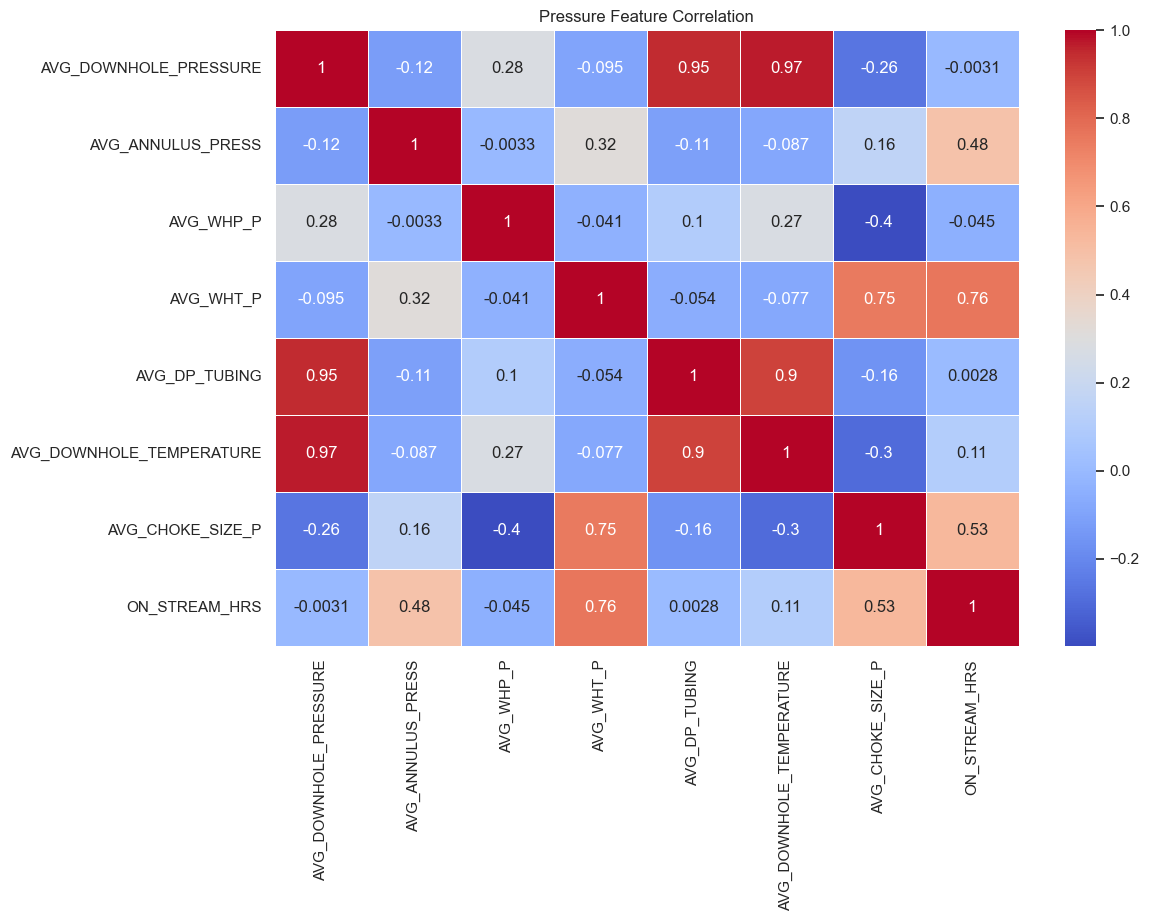

In [12]:
plt.figure(figsize=(12,8))

corr = df[pressure_features].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Pressure Feature Correlation")

plt.show()

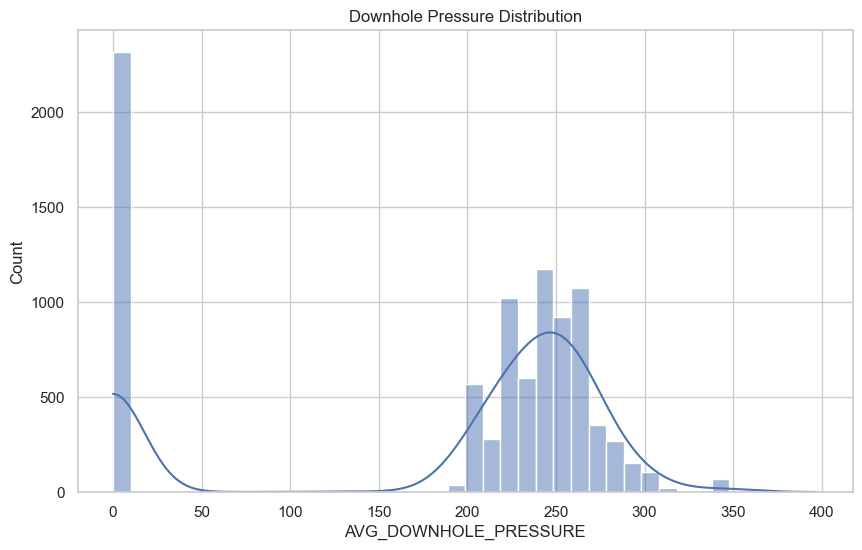

In [13]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["AVG_DOWNHOLE_PRESSURE"],
    bins=40,
    kde=True
)

plt.title("Downhole Pressure Distribution")

plt.show()

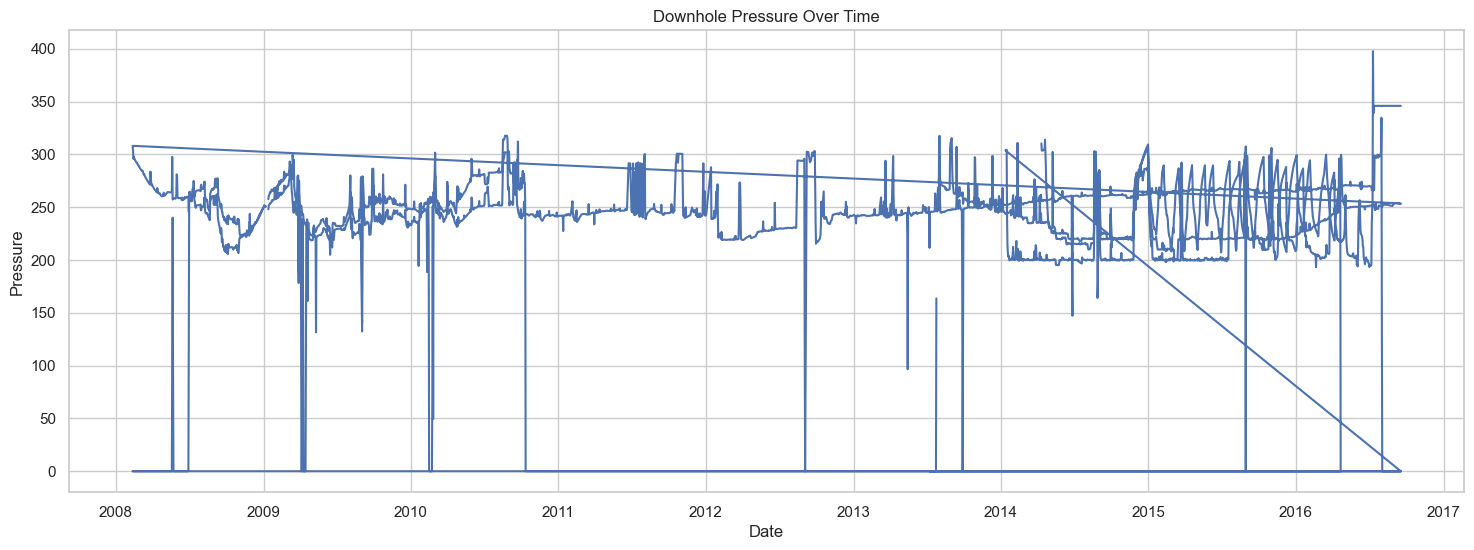

In [14]:
plt.figure(figsize=(18,6))

plt.plot(
    df["DATEPRD"],
    df["AVG_DOWNHOLE_PRESSURE"]
)

plt.title("Downhole Pressure Over Time")

plt.xlabel("Date")

plt.ylabel("Pressure")

plt.grid(True)

plt.show()

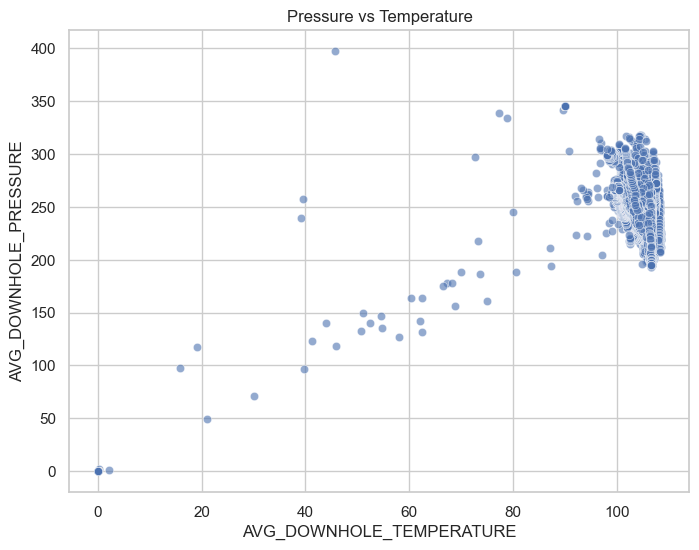

In [15]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="AVG_DOWNHOLE_TEMPERATURE",
    y="AVG_DOWNHOLE_PRESSURE",
    alpha=0.6
)

plt.title("Pressure vs Temperature")

plt.show()

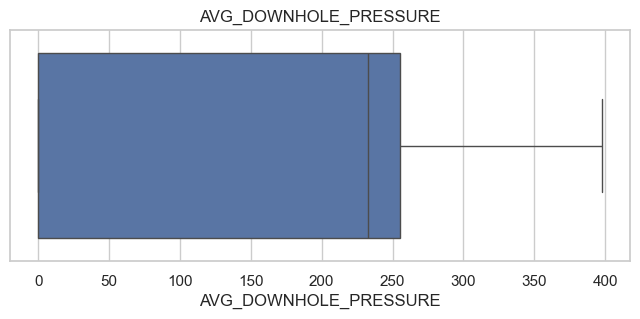

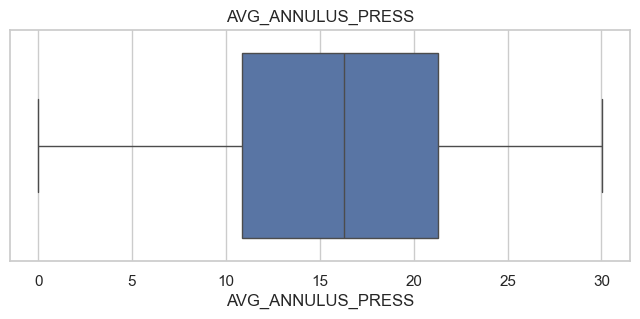

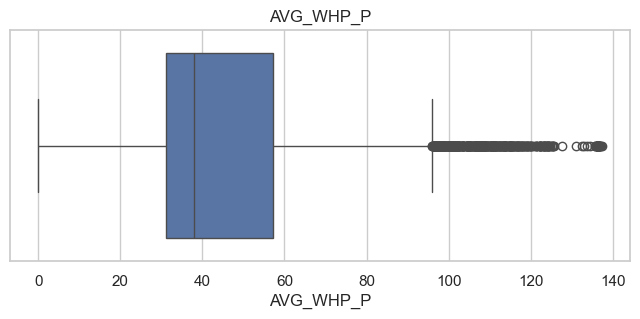

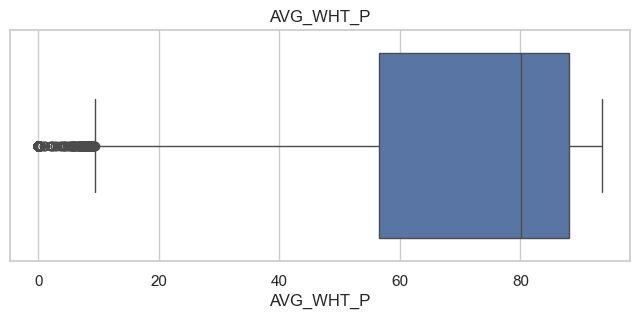

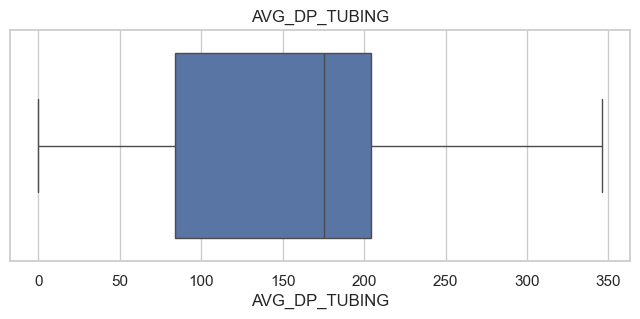

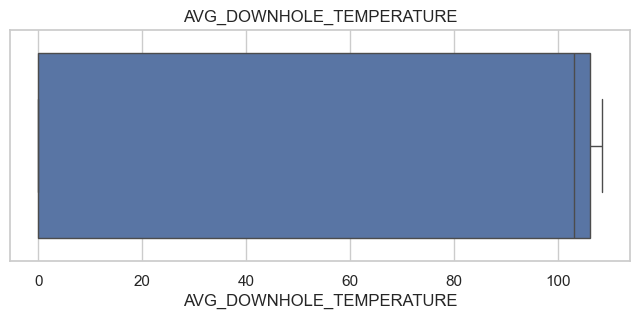

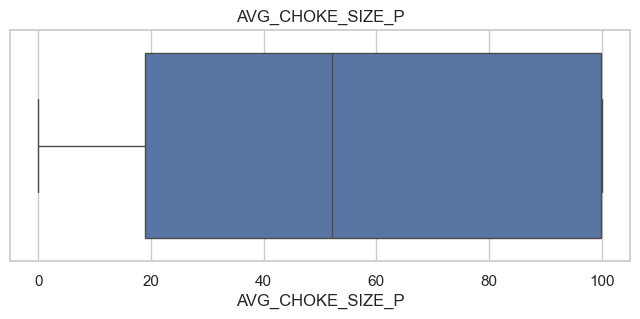

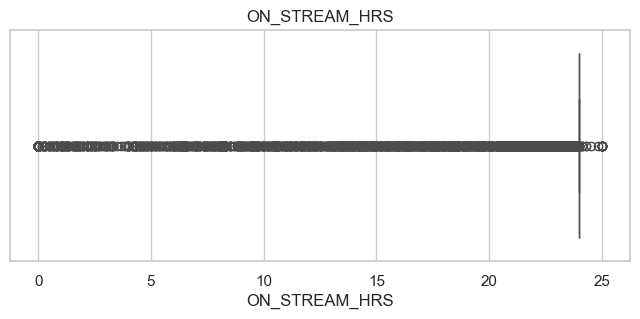

In [16]:
for column in pressure_features:

    plt.figure(figsize=(8,3))

    sns.boxplot(x=df[column])

    plt.title(column)

    plt.show()

# Machine Learning Pipeline

## Data Cleaning and Feature Engineering

Before training the Isolation Forest model, the pressure-related features are preprocessed to improve anomaly detection performance.

This stage includes:

- Handling missing values
- Removing duplicate records
- Selecting pressure-related features
- Standardizing numerical variables
- Preparing the feature matrix for anomaly detection

In [17]:
# ==========================================
# Create Working Copy
# ==========================================

df_clean = df.copy()

print("Working copy created successfully.")

print("Shape :", df_clean.shape)

Working copy created successfully.
Shape : (15634, 24)


In [18]:
# ==========================================
# Missing Values Summary
# ==========================================

missing = pd.DataFrame({
    "Missing Values": df_clean.isnull().sum(),
    "Percentage": round(
        df_clean.isnull().sum()/len(df_clean)*100,
        2
    )
})

missing[missing["Missing Values"]>0]

,Missing Values,Percentage
ON_STREAM_HRS,285,1.82
AVG_DOWNHOLE_PRESSURE,6654,42.56
AVG_DOWNHOLE_TEMPERATURE,6654,42.56
AVG_DP_TUBING,6654,42.56
AVG_ANNULUS_PRESS,7744,49.53
AVG_CHOKE_SIZE_P,6715,42.95
AVG_CHOKE_UOM,6473,41.40
AVG_WHP_P,6479,41.44
AVG_WHT_P,6488,41.50
DP_CHOKE_SIZE,294,1.88


In [19]:
# ==========================================
# Remove Columns with Excessive Missing Values
# ==========================================

threshold = len(df_clean) * 0.5

columns_to_drop = df_clean.columns[
    df_clean.isnull().sum() > threshold
]

print("Dropped Columns")

print(columns_to_drop.tolist())

df_clean.drop(
    columns=columns_to_drop,
    inplace=True
)

print("Remaining Columns :", len(df_clean.columns))

Dropped Columns
['BORE_WI_VOL']
Remaining Columns : 23


In [20]:
# ==========================================
# Fill Missing Numerical Values
# ==========================================

num_cols = df_clean.select_dtypes(
    include=np.number
).columns

for col in num_cols:

    df_clean[col].fillna(
        df_clean[col].median(),
        inplace=True
    )

print("Missing numerical values handled.")

Missing numerical values handled.


In [21]:
# ==========================================
# Fill Missing Categorical Values
# ==========================================

cat_cols = df_clean.select_dtypes(
    include="object"
).columns

for col in cat_cols:

    df_clean[col].fillna(
        df_clean[col].mode()[0],
        inplace=True
    )

print("Missing categorical values handled.")

Missing categorical values handled.


In [22]:
# ==========================================
# Remove Duplicate Records
# ==========================================

before = len(df_clean)

df_clean.drop_duplicates(
    inplace=True
)

after = len(df_clean)

print(f"Duplicates Removed : {before-after}")

Duplicates Removed : 0


In [23]:
# ==========================================
# Date Feature Engineering
# ==========================================

df_clean["YEAR"] = df_clean["DATEPRD"].dt.year

df_clean["MONTH"] = df_clean["DATEPRD"].dt.month

df_clean["DAY"] = df_clean["DATEPRD"].dt.day

df_clean["DAY_OF_WEEK"] = df_clean["DATEPRD"].dt.dayofweek

print("Date Features Created.")

Date Features Created.


In [24]:
# ==========================================
# Select Pressure Features
# ==========================================

pressure_features = [

    "AVG_DOWNHOLE_PRESSURE",

    "AVG_ANNULUS_PRESS",

    "AVG_WHP_P",

    "AVG_WHT_P",

    "AVG_DP_TUBING",

    "AVG_DOWNHOLE_TEMPERATURE",

    "AVG_CHOKE_SIZE_P",

    "ON_STREAM_HRS",

    "YEAR",

    "MONTH",

    "DAY",

    "DAY_OF_WEEK"

]

X = df_clean[pressure_features]

print("Feature Matrix Shape")

print(X.shape)

Feature Matrix Shape
(15634, 12)


In [25]:
# ==========================================
# Handle Infinite Values
# ==========================================

X.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

X.fillna(
    X.median(),
    inplace=True
)

print("Infinite values handled.")

Infinite values handled.


In [26]:
# ==========================================
# Feature Scaling
# ==========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature Scaling Completed.")

print(X_scaled.shape)

Feature Scaling Completed.
(15634, 12)


# Isolation Forest Model

Isolation Forest is an unsupervised anomaly detection algorithm that isolates abnormal observations by recursively partitioning the feature space.

Unlike supervised learning models, Isolation Forest does not require labeled anomalies. Instead, it assigns an anomaly score to each observation based on how easily it can be isolated.

Observations identified as anomalies are assigned a prediction value of **-1**, while normal observations receive a value of **1**.

In [27]:
# ==========================================
# Train Isolation Forest
# ==========================================

iso_model = IsolationForest(

    contamination=0.02,

    n_estimators=300,

    max_samples="auto",

    random_state=42

)

iso_model.fit(X_scaled)

print("Isolation Forest Trained Successfully.")

Isolation Forest Trained Successfully.


In [28]:
# ==========================================
# Detect Anomalies
# ==========================================

predictions = iso_model.predict(X_scaled)

scores = iso_model.decision_function(X_scaled)

df_clean["Anomaly"] = predictions

df_clean["Anomaly Score"] = scores

print(df_clean["Anomaly"].value_counts())

Anomaly
 1    15321
-1      313
Name: count, dtype: int64


In [29]:
# ==========================================
# Anomaly Summary
# ==========================================

anomaly_count = (
    df_clean["Anomaly"] == -1
).sum()

normal_count = (
    df_clean["Anomaly"] == 1
).sum()

print(f"Normal Samples : {normal_count}")

print(f"Anomalies : {anomaly_count}")

print(f"Percentage : {anomaly_count/len(df_clean)*100:.2f}%")

Normal Samples : 15321
Anomalies : 313
Percentage : 2.00%


# Advanced Pressure Anomaly Analysis

This section visualizes the anomalies detected by the Isolation Forest model using multiple analytical techniques.

The objectives are to:

- Visualize anomaly locations over time
- Understand anomaly distribution
- Reduce dimensionality using PCA
- Analyze pressure health trends
- Identify high-risk wells
- Generate an operational pressure health assessment

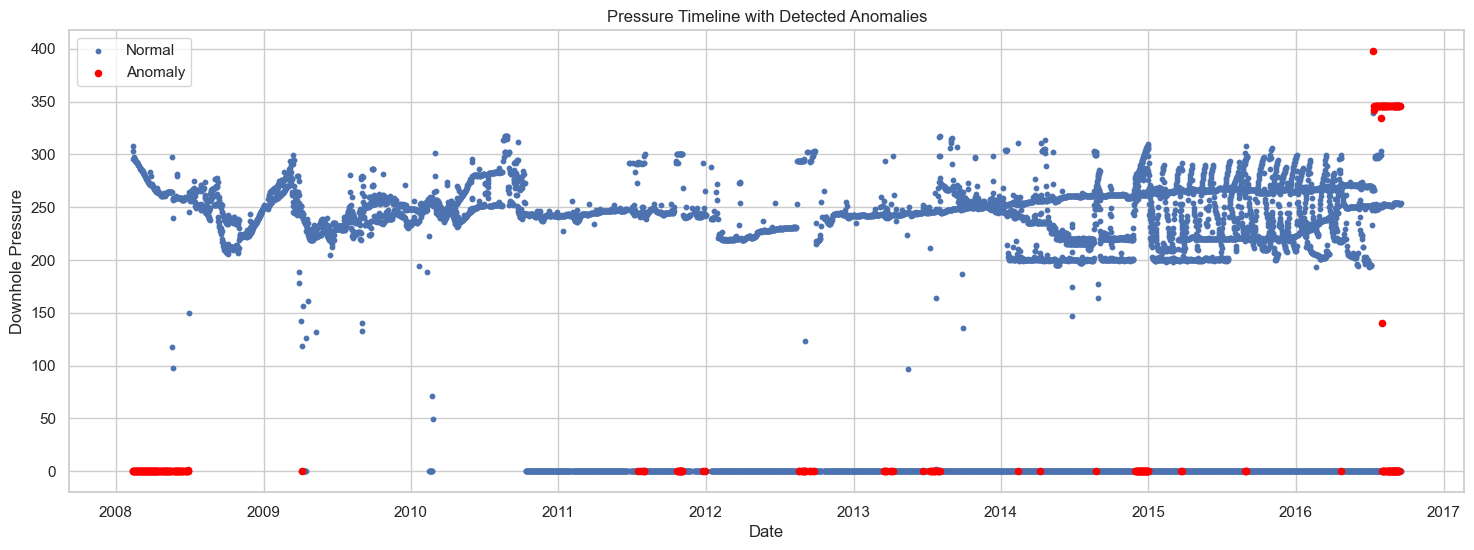

In [30]:
# ==========================================
# Pressure Timeline with Anomalies
# ==========================================

plt.figure(figsize=(18,6))

normal = df_clean[df_clean["Anomaly"] == 1]
anomaly = df_clean[df_clean["Anomaly"] == -1]

plt.scatter(
    normal["DATEPRD"],
    normal["AVG_DOWNHOLE_PRESSURE"],
    s=10,
    label="Normal"
)

plt.scatter(
    anomaly["DATEPRD"],
    anomaly["AVG_DOWNHOLE_PRESSURE"],
    color="red",
    s=20,
    label="Anomaly"
)

plt.title("Pressure Timeline with Detected Anomalies")

plt.xlabel("Date")

plt.ylabel("Downhole Pressure")

plt.legend()

plt.grid(True)

plt.show()

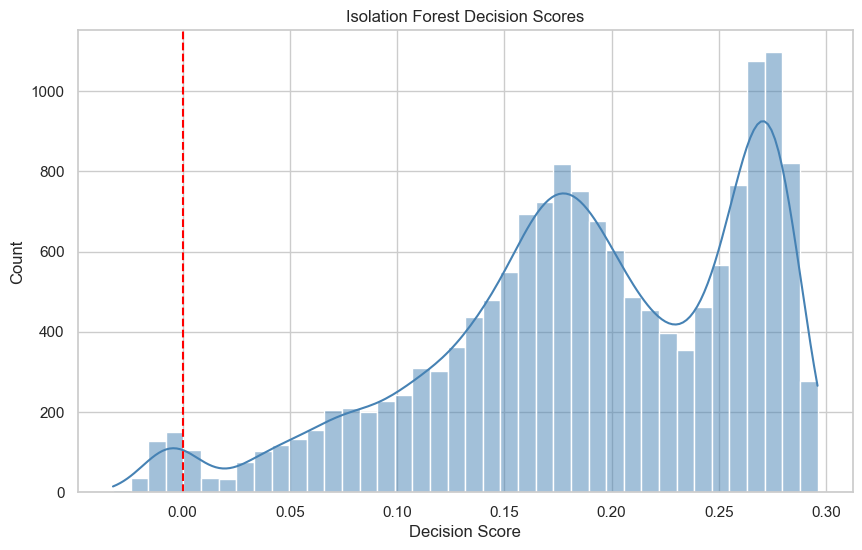

In [31]:
# ==========================================
# Decision Function Distribution
# ==========================================

plt.figure(figsize=(10,6))

sns.histplot(
    df_clean["Anomaly Score"],
    bins=40,
    kde=True,
    color="steelblue"
)

plt.axvline(
    x=0,
    color="red",
    linestyle="--"
)

plt.title("Isolation Forest Decision Scores")

plt.xlabel("Decision Score")

plt.show()

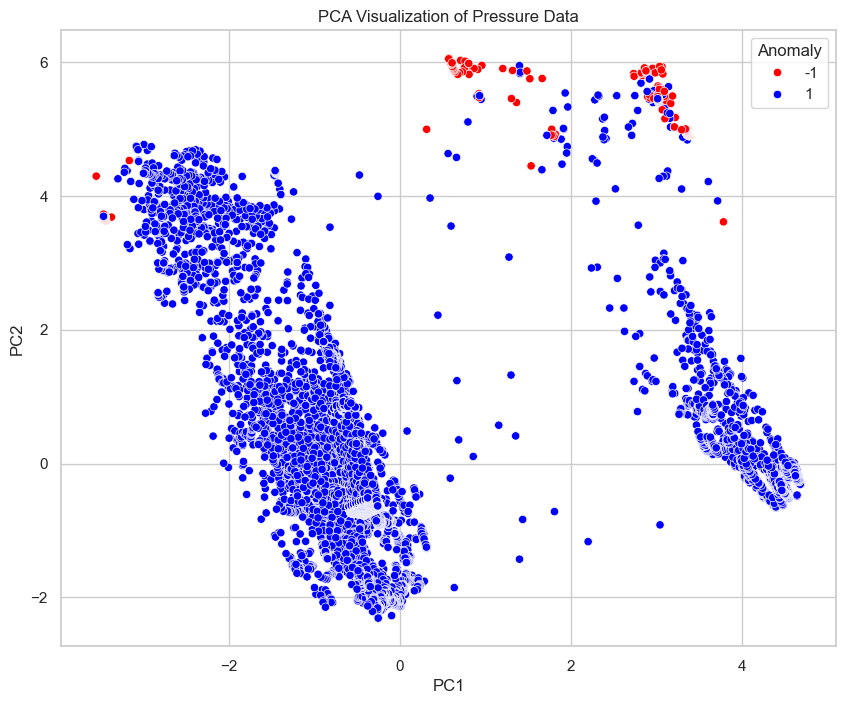

In [32]:
# ==========================================
# PCA Projection
# ==========================================

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "Anomaly": predictions
})

plt.figure(figsize=(10,8))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Anomaly",
    palette={
        1:"blue",
        -1:"red"
    }
)

plt.title("PCA Visualization of Pressure Data")

plt.show()

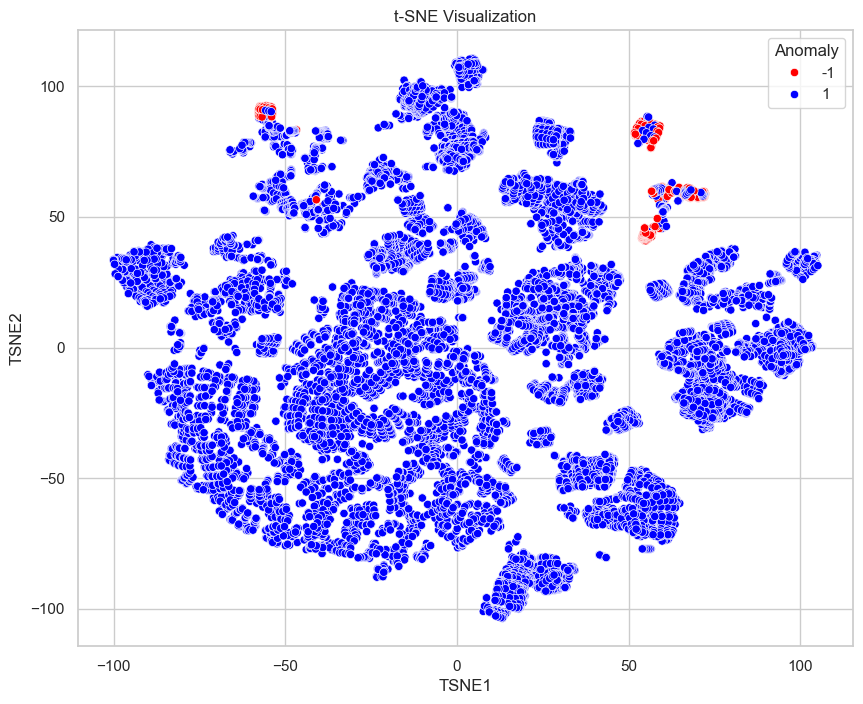

In [33]:
# ==========================================
# t-SNE Projection
# ==========================================

from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

tsne_df = pd.DataFrame({
    "TSNE1": X_tsne[:,0],
    "TSNE2": X_tsne[:,1],
    "Anomaly": predictions
})

plt.figure(figsize=(10,8))

sns.scatterplot(
    data=tsne_df,
    x="TSNE1",
    y="TSNE2",
    hue="Anomaly",
    palette={
        1:"blue",
        -1:"red"
    }
)

plt.title("t-SNE Visualization")

plt.show()

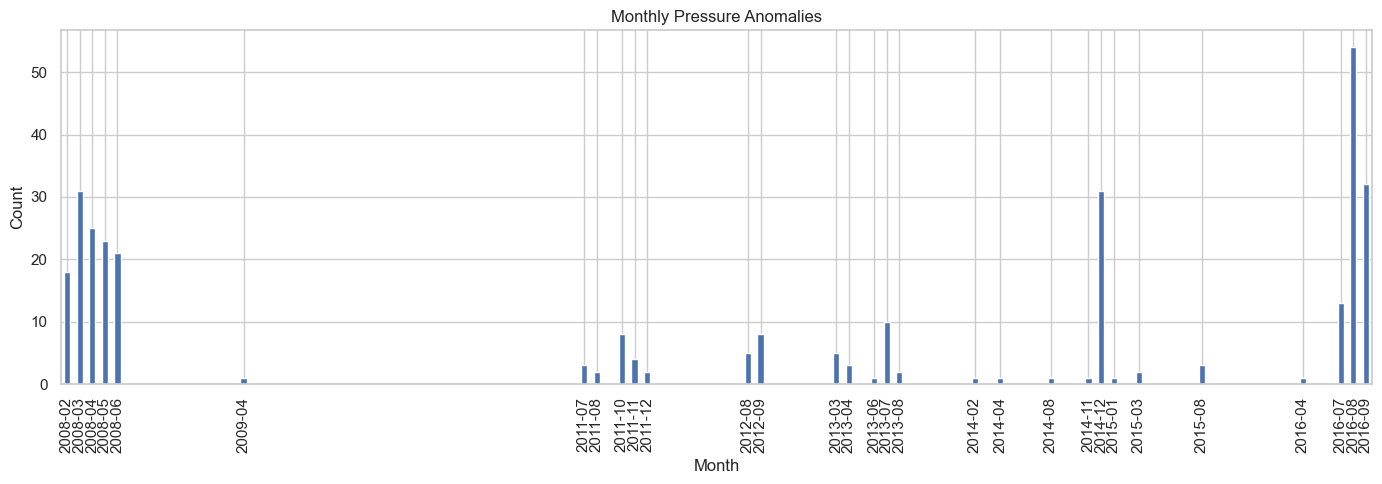

In [34]:
# ==========================================
# Monthly Anomaly Count
# ==========================================

monthly = df_clean.copy()

monthly["Month"] = monthly["DATEPRD"].dt.to_period("M")

monthly = (
    monthly[monthly["Anomaly"]==-1]
    .groupby("Month")
    .size()
)

plt.figure(figsize=(14,5))

monthly.plot(kind="bar")

plt.title("Monthly Pressure Anomalies")

plt.ylabel("Count")

plt.tight_layout()

plt.show()

In [35]:
# ==========================================
# Pressure Health Score
# ==========================================

score = df_clean["Anomaly Score"]

health_score = (
    (
        score-score.min()
    ) /
    (
        score.max()-score.min()
    )
)*100

df_clean["Pressure Health Score"] = health_score

df_clean[
    [
        "Pressure Health Score",
        "Anomaly"
    ]
].head()

,Pressure Health Score,Anomaly
0,4.911624,-1
1,30.355927,1
2,32.363000,1
3,32.604475,1
4,24.071567,1


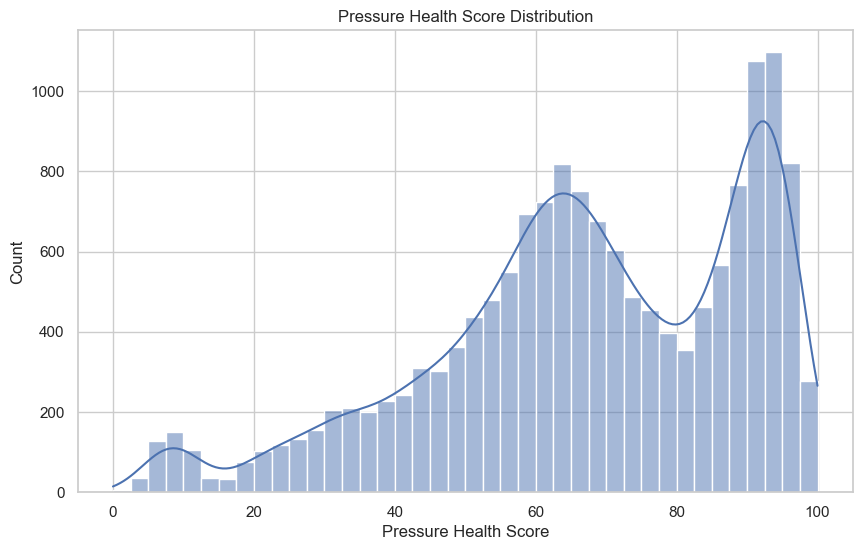

In [36]:
# ==========================================
# Pressure Health Score Distribution
# ==========================================

plt.figure(figsize=(10,6))

sns.histplot(
    df_clean["Pressure Health Score"],
    bins=40,
    kde=True
)

plt.title("Pressure Health Score Distribution")

plt.show()

In [37]:
# ==========================================
# Most Critical Pressure Events
# ==========================================

critical = df_clean.sort_values(
    by="Pressure Health Score"
)

critical[
    [
        "DATEPRD",
        "NPD_WELL_BORE_NAME",
        "AVG_DOWNHOLE_PRESSURE",
        "Pressure Health Score"
    ]
].head(20)

,DATEPRD,NPD_WELL_BORE_NAME,AVG_DOWNHOLE_PRESSURE,Pressure Health Score
5014,2008-03-30,15/9-F-14,0.00000,0.000000
4987,2008-03-03,15/9-F-14,0.00000,1.354587
5015,2008-03-31,15/9-F-14,0.00000,1.564149
8953,2016-08-01,15/9-F-15 D,345.60328,2.134468
4337,2014-12-28,15/9-F-12,0.00000,2.155920
5076,2008-06-01,15/9-F-14,0.00000,2.488659
4986,2008-03-02,15/9-F-14,0.00000,2.652526
5077,2008-06-02,15/9-F-14,0.00000,2.744595
4310,2014-12-01,15/9-F-12,0.00000,3.028681
4980,2008-02-25,15/9-F-14,0.00000,3.075458


In [38]:
# ==========================================
# Most Critical Pressure Events
# ==========================================

critical = df_clean.sort_values(
    by="Pressure Health Score"
)

critical[
    [
        "DATEPRD",
        "NPD_WELL_BORE_NAME",
        "AVG_DOWNHOLE_PRESSURE",
        "Pressure Health Score"
    ]
].head(20)

,DATEPRD,NPD_WELL_BORE_NAME,AVG_DOWNHOLE_PRESSURE,Pressure Health Score
5014,2008-03-30,15/9-F-14,0.00000,0.000000
4987,2008-03-03,15/9-F-14,0.00000,1.354587
5015,2008-03-31,15/9-F-14,0.00000,1.564149
8953,2016-08-01,15/9-F-15 D,345.60328,2.134468
4337,2014-12-28,15/9-F-12,0.00000,2.155920
5076,2008-06-01,15/9-F-14,0.00000,2.488659
4986,2008-03-02,15/9-F-14,0.00000,2.652526
5077,2008-06-02,15/9-F-14,0.00000,2.744595
4310,2014-12-01,15/9-F-12,0.00000,3.028681
4980,2008-02-25,15/9-F-14,0.00000,3.075458


In [39]:
# ==========================================
# Save Model
# ==========================================

joblib.dump(
    iso_model,
    "pressure_model.pkl"
)

joblib.dump(
    scaler,
    "pressure_scaler.pkl"
)

joblib.dump(
    pressure_features,
    "pressure_features.pkl"
)

df_clean.to_csv(
    "pressure_cleaned.csv",
    index=False
)

print("Model Saved Successfully.")

Model Saved Successfully.


In [40]:
# ==========================================
# Save Model
# ==========================================

joblib.dump(
    iso_model,
    "pressure_model.pkl"
)

joblib.dump(
    scaler,
    "pressure_scaler.pkl"
)

joblib.dump(
    pressure_features,
    "pressure_features.pkl"
)

df_clean.to_csv(
    "pressure_cleaned.csv",
    index=False
)

print("Model Saved Successfully.")

Model Saved Successfully.
